In [ ]:
!git clone https://github.com/shadow2496/VITON-HD

Cloning into 'VITON-HD'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 46 (delta 8), reused 7 (delta 6), pack-reused 31 (from 1)
Receiving objects: 100% (46/46), 5.03 MiB | 21.28 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [ ]:
ls

sample_data/  VITON-HD/


In [ ]:
pip install torch torchvision

In [ ]:
pip install opencv-python torchgeometry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.3 MB/s eta 0:00:00


In [ ]:
ls

sample_data/  VITON-HD/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd VITON-HD/

/content/VITON-HD


In [ ]:
ls

assets/  checkpoints/  datasets/  datasets.py  LICENSE  networks.py  README.md  test.py  utils.py


In [ ]:
cp /content/drive/MyDrive/VITON-HD/checkpoints/* checkpoints/

In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/* datasets/

cp: -r not specified; omitting directory '/content/drive/MyDrive/VITON-HD/datasets/test'


In [ ]:
cd datasets/


/content/VITON-HD/datasets


In [ ]:
mkdir -p test/image

In [ ]:
mkdir -p test/cloth

In [ ]:
mkdir -p test/cloth-mask

In [ ]:
mkdir -p test/image-parse

In [ ]:
mkdir -p test/openpose-img

In [ ]:
mkdir -p test/openpose-json

In [ ]:
ls

test/  test_pairs.txt


In [ ]:
cd test

/content/VITON-HD/datasets/test


In [ ]:
ls

cloth/  cloth-mask/  image/  image-parse/  openpose-img/  openpose-json/


In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/test/image/* image/

In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/test/cloth/* cloth/

In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/test/cloth-mask/* cloth-mask/

In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/test/image-parse/* image-parse/

In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/test/openpose-img/* openpose-img/

In [ ]:
cp /content/drive/MyDrive/VITON-HD/datasets/test/openpose-json/* openpose-json/

In [ ]:
ls

cloth/  cloth-mask/  image/  image-parse/  openpose-img/  openpose-json/


In [ ]:
cd ..

/content/VITON-HD/datasets


In [ ]:
cd ..

/content/VITON-HD


In [ ]:
!python test.py --name viton_hd_test

Namespace(name='viton_hd_test', batch_size=1, workers=1, load_height=1024, load_width=768, shuffle=False, dataset_dir='./datasets/', dataset_mode='test', dataset_list='test_pairs.txt', checkpoint_dir='./checkpoints/', save_dir='./results/', display_freq=1, seg_checkpoint='seg_final.pth', gmm_checkpoint='gmm_final.pth', alias_checkpoint='alias_final.pth', semantic_nc=13, init_type='xavier', init_variance=0.02, grid_size=5, norm_G='spectralaliasinstance', ngf=64, num_upsampling_layers='most')
Network [SegGenerator] was created. Total number of parameters: 34.5 million. To see the architecture, do print(network).
Network [ALIASGenerator] was created. Total number of parameters: 100.5 million. To see the architecture, do print(network).
/content/VITON-HD/utils.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary c

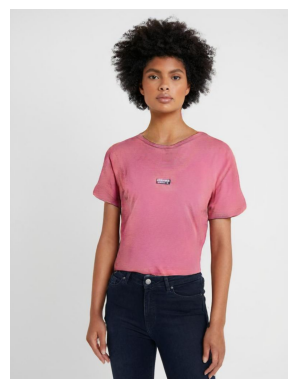

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

# Show sample results
output_images = glob.glob('results/viton_hd_test/*.jpg')
for img_path in output_images[:5]:  # Show the first 5 results
    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [ ]:
!pip install flask flask_cors pyngrok

In [ ]:
!pip install boto3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.6/82.6 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip install flask-cors

In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
import os
from pyngrok import ngrok
import boto3
from botocore.exceptions import NoCredentialsError


# Initialize Flask app
app = Flask(__name__)
CORS(app, resources={r"/try-on": {"origins": "*"}})  # Enable CORS for cross-origin requests

# Expose Colab with ngrok
public_url = ngrok.connect(5000)
print(f"Public URL: {public_url}")

# Initialize S3 client
s3 = boto3.client('s3')
bucket_name = 'sw-uploads-img'

def upload_to_s3(file_name, bucket, object_name=None):
    """Upload a file to an S3 bucket and return the file URL."""
    if object_name is None:
        object_name = file_name

    try:
        s3.upload_file(file_name, bucket, object_name)
        print(f"Uploaded {file_name} to {bucket}/{object_name}")

        # Construct the URL for the uploaded file
        s3_url = f"https://{bucket}.s3.eu-north-1.amazonaws.com/{object_name}"
        return s3_url
    except FileNotFoundError:
        print(f"The file {file_name} was not found")
        return None
    except NoCredentialsError:
        print("Credentials not available")
        return None

def check_s3_for_existing_image(user_image_name, cloth_image_name):
    """Check if the try-on image already exists in S3."""
    object_name = f"{user_image_name}_{cloth_image_name}"
    try:
        s3.head_object(Bucket=bucket_name, Key=object_name)
        s3_url = f"https://{bucket_name}.s3.eu-north-1.amazonaws.com/{object_name}"
        return s3_url
    except s3.exceptions.ClientError:
        return None

@app.route('/try-on', methods=['POST'])
def virtual_try_on():
    # Parse request data for cloth image name
    data = request.get_json()
    if not data or 'cloth_image_name' not in data:
        return jsonify({'error': 'Cloth image name is required'}), 400

    cloth_image_name = data['cloth_image_name']
    uploaded_image_links = []

    user_image_names = [
        "00034",
        "00035",
        "00071",
        "00135",
        "00373",
        "00814"
    ]

    # Check for each user-cloth pair in S3
    new_pairs_to_generate = []
    for user_image_name in user_image_names:
        existing_image_url = check_s3_for_existing_image(user_image_name, cloth_image_name)
        if existing_image_url:
            uploaded_image_links.append(existing_image_url)
            print(f"Found existing try-on for {user_image_name} and {cloth_image_name} in S3")
        else:
            # Add the pair to the list if it doesn't exist in S3
            new_pairs_to_generate.append(user_image_name)

    user_image_names = [
        "00034_00.jpg",
        "00035_00.jpg",
        "00071_00.jpg",
        "00135_00.jpg",
        "00373_00.jpg",
        "00814_00.jpg"
    ]

    # Write new pairs to test_pairs.txt if any
    if new_pairs_to_generate:
        with open('datasets/test_pairs.txt', 'w') as f:
            for user_image_name in user_image_names:
                f.write(f"{user_image_name} {cloth_image_name}\n")

        # Run VITON-HD model for new pairs in test_pairs.txt
        os.system('python test.py --name viton_hd_test')

        user_image_names = [
        "00034",
        "00035",
        "00071",
        "00135",
        "00373",
        "00814"
        ]

        #Upload newly generated output images to S3 if they were not found previously
        for user_image_name in user_image_names:
            output_image_path = f"results/viton_hd_test/{user_image_name}_{cloth_image_name}"  # Adjust to your output image naming convention
            uploaded_image_url = upload_to_s3(output_image_path, bucket_name, f"{user_image_name}_{cloth_image_name}")

            if uploaded_image_url:
                uploaded_image_links.append(uploaded_image_url)
            else:
                print(f"Failed to upload {output_image_path} to S3")

    # Return the list of uploaded image URLs
    return jsonify({
        'message': 'Virtual try-on completed and images uploaded to S3',
        'image_links': uploaded_image_links
    }), 200

if __name__ == '__main__':
    app.run(port=5000)


Public URL: NgrokTunnel: "https://a354-34-34-57-13.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [28/Oct/2024 23:10:13] "POST /try-on HTTP/1.1" 200 -


Found existing try-on for 00034 and 00013_00.jpg in S3
Found existing try-on for 00035 and 00013_00.jpg in S3
Found existing try-on for 00071 and 00013_00.jpg in S3
Found existing try-on for 00135 and 00013_00.jpg in S3
Found existing try-on for 00373 and 00013_00.jpg in S3
Found existing try-on for 00814 and 00013_00.jpg in S3
Uploaded results/viton_hd_test/00034_00067_00.jpg to sw-uploads-img/00034_00067_00.jpg
Uploaded results/viton_hd_test/00035_00067_00.jpg to sw-uploads-img/00035_00067_00.jpg
Uploaded results/viton_hd_test/00071_00067_00.jpg to sw-uploads-img/00071_00067_00.jpg
Uploaded results/viton_hd_test/00135_00067_00.jpg to sw-uploads-img/00135_00067_00.jpg


INFO:werkzeug:127.0.0.1 - - [28/Oct/2024 23:10:59] "POST /try-on HTTP/1.1" 200 -


Uploaded results/viton_hd_test/00373_00067_00.jpg to sw-uploads-img/00373_00067_00.jpg
Uploaded results/viton_hd_test/00814_00067_00.jpg to sw-uploads-img/00814_00067_00.jpg


...

Uploaded results/viton_hd_test/00034_00035_00.jpg to sw-uploads-img/00034_00035_00.jpg
Uploaded results/viton_hd_test/00035_00035_00.jpg to sw-uploads-img/00035_00035_00.jpg
Uploaded results/viton_hd_test/00071_00035_00.jpg to sw-uploads-img/00071_00035_00.jpg


INFO:werkzeug:127.0.0.1 - - [28/Oct/2024 23:17:09] "POST /try-on HTTP/1.1" 200 -


Uploaded results/viton_hd_test/00135_00035_00.jpg to sw-uploads-img/00135_00035_00.jpg
Uploaded results/viton_hd_test/00373_00035_00.jpg to sw-uploads-img/00373_00035_00.jpg
Uploaded results/viton_hd_test/00814_00035_00.jpg to sw-uploads-img/00814_00035_00.jpg


INFO:werkzeug:127.0.0.1 - - [28/Oct/2024 23:17:26] "POST /try-on HTTP/1.1" 200 -


Found existing try-on for 00034 and 00035_00.jpg in S3
Found existing try-on for 00035 and 00035_00.jpg in S3
Found existing try-on for 00071 and 00035_00.jpg in S3
Found existing try-on for 00135 and 00035_00.jpg in S3
Found existing try-on for 00373 and 00035_00.jpg in S3
Found existing try-on for 00814 and 00035_00.jpg in S3
